In [1]:
# imports : Random Forest

# Core Data Manipulation
import pandas as pd
import os #dont import if you are not using kaggle cell

# Model Selection, Estimator, & Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

# Imbalanced Learning & Leak-Free Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Safe resampling pipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress potential warnings for clean notebook execution
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ignore this cell if you are not using Kaggle notebook. 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


# Phase 1: Data Ingestion & Stratified Splitting

In [ ]:

# 1. Load the Credit Card Fraud Detection Dataset
df = pd.read_csv('Your_File_Path_Here.csv')  # Replace with your actual file path

# 2. Extract Features (X) and Target Label (y)
# 'Class' is our target where 0 = Legitimate, 1 = Fraudulent
X = df.drop(columns=['Class'])
y = df['Class']

# 3. Verify Extreme Class Imbalance Ratio Before Splitting
print("--- Baseline Class Distribution ---")
total_pool = len(df)
legit_count = (y == 0).sum()
fraud_count = (y == 1).sum()

print(f"Total Transaction Pool: {total_pool:,}")
print(f"Legitimate Volume: {legit_count:,} ({legit_count/total_pool*100:.2f}%)")
print(f"Fraudulent Volume: {fraud_count:,} ({fraud_count/total_pool*100:.2f}%)")
print("-" * 35)

# 4. Execute the Stratified Train/Test Split (80/20)
# stratify=y guarantees the 0.17% fraud ratio is perfectly preserved in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("\n--- Split Verification ---")
print(f"X_train Shape: {X_train.shape} | Fraud Ratio: {(y_train == 1).sum()/len(y_train)*100:.3f}%")
print(f"X_test Shape:  {X_test.shape}  | Fraud Ratio: {(y_test == 1).sum()/len(y_test)*100:.3f}%")
print("\n[LEAK-FREE GUARDRAIL ACTIVE]: Raw test structures successfully isolated.")

--- Baseline Class Distribution ---
Total Transaction Pool: 284,807
Legitimate Volume: 284,315 (99.83%)
Fraudulent Volume: 492 (0.17%)
-----------------------------------

--- Split Verification ---
X_train Shape: (227845, 30) | Fraud Ratio: 0.173%
X_test Shape:  (56962, 30)  | Fraud Ratio: 0.172%

[LEAK-FREE GUARDRAIL ACTIVE]: Raw test structures successfully isolated.


# PHASE 2: ENSEMBLE PIPELINE ARCHITECTURE

In [4]:

# Constructing the non-linear ensemble pipeline without a scaler
rf_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),            # 1. Resampling Chamber (Direct synthesis)
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)) # 2. Ensemble Estimator
])

print("--- Notebook 2 Pipeline Blueprint ---")
print(rf_pipeline)
print("\n[COMPUTATIONAL NOTE]: StandardScaler omitted.Tree partitions remain perfectly scale-invariant.")

--- Notebook 2 Pipeline Blueprint ---
Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

[COMPUTATIONAL NOTE]: StandardScaler omitted.Tree partitions remain perfectly scale-invariant.


# PHASE 3: HOLISTIC HYPERPARAMETER TUNING (RANDOM FOREST)

In [5]:

# 1. Define the parameter grid for the ensemble tree architecture
param_grid_rf = {
    'smote__k_neighbors': [3, 5, 7],               # Tuning the neighborhood framework
    'classifier__max_depth': [10, 20, None],       # Structural depth constraints
    'classifier__n_estimators': [100, 200]         # Total number of decision trees
}

# 2. Instantiate GridSearchCV with 5-Fold Stratified Cross-Validation
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 3. Trigger the safe training loop
print("--- Launching Random Forest Grid Search (5-Fold CV) ---")
grid_rf.fit(X_train, y_train)

print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {grid_rf.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_rf.best_score_:.4f}")

--- Launching Random Forest Grid Search (5-Fold CV) ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- Tuning Complete ---
Best Parameters Found: {'classifier__max_depth': 10, 'classifier__n_estimators': 200, 'smote__k_neighbors': 3}
Best Cross-Validated ROC-AUC: 0.9842


# PHASE 4: STRICT EVALUATION FRAMEWORK (RANDOM FOREST)

         RANDOM FOREST FINAL EVALUATION           
Strict Precision Score : 0.5478
Strict Recall Score    : 0.8776
Final ROC-AUC Benchmark: 0.9823 (Target: 0.85+)
--------------------------------------------------

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     56864
Fraudulent (1)       0.55      0.88      0.67        98

      accuracy                           1.00     56962
     macro avg       0.77      0.94      0.84     56962
  weighted avg       1.00      1.00      1.00     56962



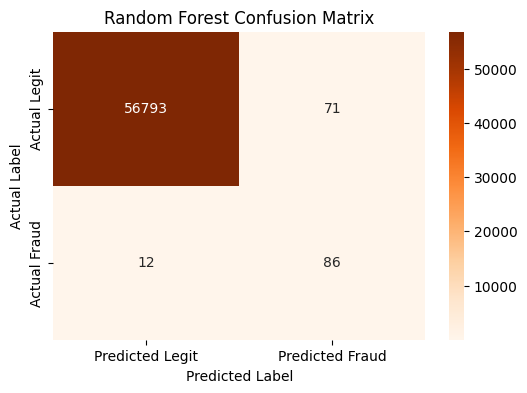

In [6]:

# 1. Extract the optimized ensemble model from GridSearchCV
best_rf_model = grid_rf.best_estimator_

# 2. Predict on the untouched, raw test data
y_pred_rf = best_rf_model.predict(X_test)
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

# 3. Calculate metrics under strict financial guardrails
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("==================================================")
print("         RANDOM FOREST FINAL EVALUATION           ")
print("==================================================")
print(f"Strict Precision Score : {precision_rf:.4f}")
print(f"Strict Recall Score    : {recall_rf:.4f}")
print(f"Final ROC-AUC Benchmark: {roc_auc_rf:.4f} (Target: 0.85+)")
print("-" * 50)

# 4. Print Complete Classification Breakdown
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate (0)', 'Fraudulent (1)']))

# 5. Plot the Confusion Matrix Graph
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title("Random Forest Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()